In [13]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.gridspec as gridspec
from scipy.stats import gaussian_kde
from scipy.signal import savgol_filter
from matplotlib.ticker import AutoMinorLocator
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import warnings

from scipy.spatial.distance import pdist
import seaborn as sns
from scipy.spatial.distance import cdist
import matplotlib.gridspec as gridspec
from matplotlib.ticker import MultipleLocator
from matplotlib.ticker import MaxNLocator
import glob



warnings.simplefilter(action='ignore', category=FutureWarning)

# DEMOGRAPHIC RECOVERY 

# HETEROGENEOUS SCENARIO

In [14]:
SIZE_TITLE = 40        
SIZE_LABEL = 38      
SIZE_TICK = 34         
SIZE_LEGEND = 28       

plt.rcParams['text.usetex'] = True
plt.rcParams.update({
    'font.family': 'sans-serif',
    'text.latex.preamble': r'\usepackage{sfmath} \renewcommand{\familydefault}{\sfdefault} \normalfont',
})


In [15]:

colunas = ['id', 'x', 'y', 'especie', 'grau', 'fenotipo', 'fitness']

dirs = {
    'RS': 'DATA/heterogeneous/G5sigma5/All/',
    'RW': 'DATA/heterogeneous/G5sigma40/All/',
    'PS': 'DATA/heterogeneous/G30sigma5/All/',
    'PW': 'DATA/heterogeneous/G30sigma40/All/',
}

styles = {
    'RS': {'c': '#e41a1c', 'ls': '-',  'lw': 4.0, 'z': 4}, # Vermelho
    'RW': {'c': '#377eb8', 'ls': '--', 'lw': 4.0, 'z': 3}, # Azul
    'PS': {'c': '#4daf4a', 'ls': '-.', 'lw': 4.0, 'z': 2}, # Verde
    'PW': {'c': '#ff7f00', 'ls': ':',  'lw': 4.5, 'z': 1}, # Laranja
}



In [16]:
def extrair_dinamica_global(pasta, t_max=1000):
    tempos = []
    variancia_fenotipo = []
    fitness_medio = []
    
    for t in range(t_max + 1):
        arquivo = os.path.join(pasta, f'data{t}.dat')
        if not os.path.exists(arquivo):
            continue
            
        try:
            df = pd.read_csv(arquivo, sep=r'\s+', names=colunas, header=None)
            var_fen = df['fenotipo'].var()
            fit_med = df['fitness'].mean()
            
            tempos.append(t)
            variancia_fenotipo.append(var_fen)
            fitness_medio.append(fit_med)
            
        except Exception as e:
            pass 
    return np.array(tempos), np.array(variancia_fenotipo), np.array(fitness_medio)

def format_ax(a, major_size=SIZE_TICK, is_int=False):
    a.tick_params(which='both', direction='in', top=True, right=True)
    a.tick_params(which='major', length=12, width=2.0, labelsize=major_size, pad=10)
    a.xaxis.set_minor_locator(AutoMinorLocator(5))
    a.yaxis.set_minor_locator(AutoMinorLocator(5))
    for spine in a.spines.values(): 
        spine.set_linewidth(2.0)
    fmt = r'$\mathsf{%d}$' if is_int else r'$\mathsf{%g}$'
    a.xaxis.set_major_formatter(ticker.FormatStrFormatter(fmt))
    a.yaxis.set_major_formatter(ticker.FormatStrFormatter(fmt))




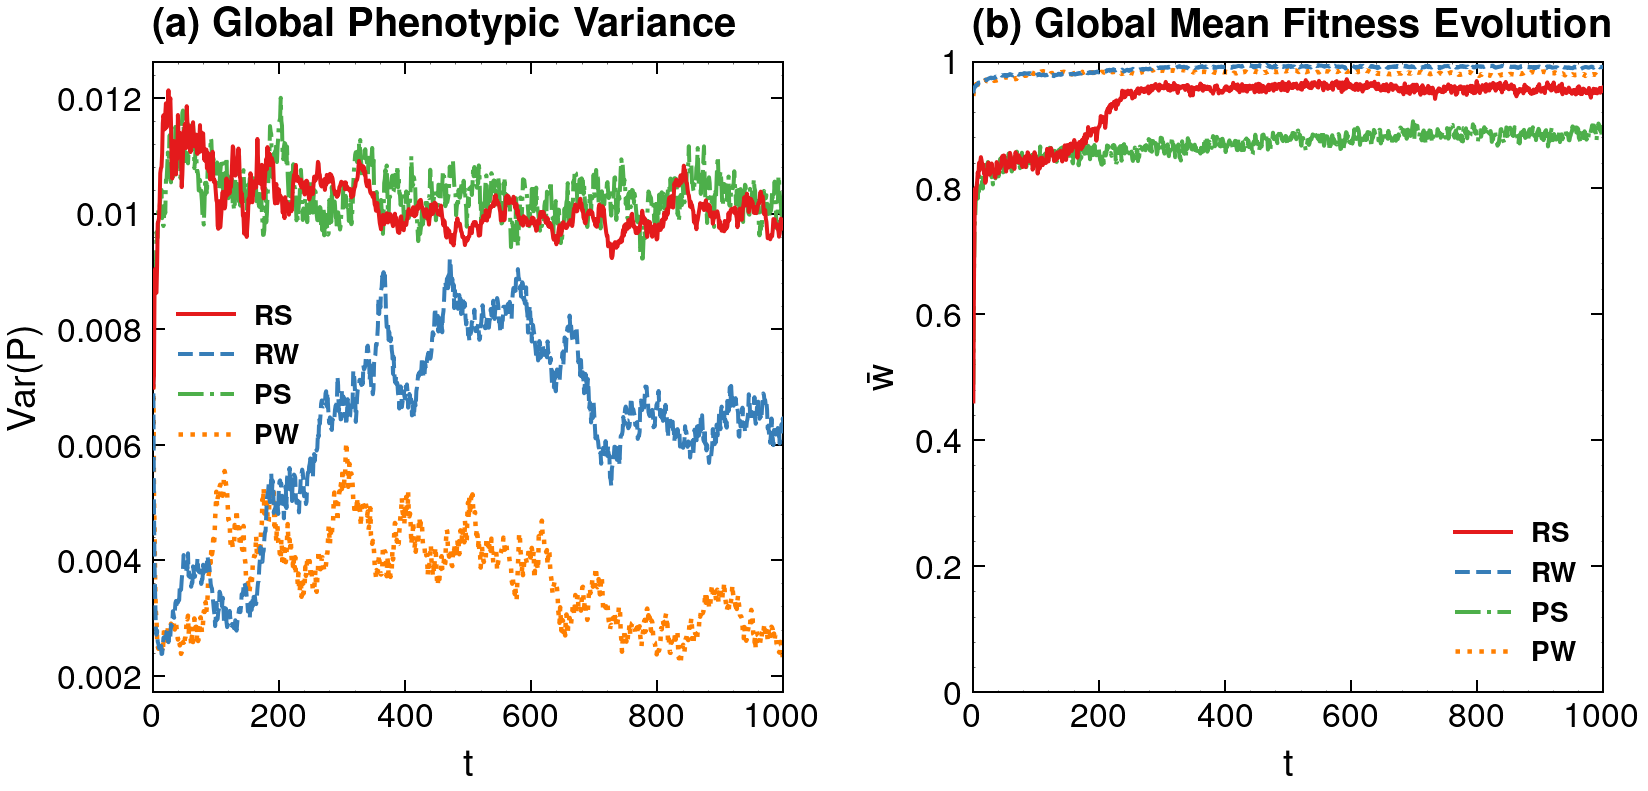

In [17]:
dados_extraidos = {}

for label, pasta in dirs.items():
    t_arr, var_arr, fit_arr = extrair_dinamica_global(pasta, t_max=1000)
    dados_extraidos[label] = {'t': t_arr, 'var': var_arr, 'fit': fit_arr}

fig = plt.figure(figsize=(26, 12))
gs = gridspec.GridSpec(1, 2, wspace=0.30)

ax1 = fig.add_subplot(gs[0, 0])
ax1.set_box_aspect(1) 

for label, data in dados_extraidos.items():
    if len(data['t']) > 0: 
        cfg = styles[label]
        ax1.plot(data['t'], data['var'], color=cfg['c'], linestyle=cfg['ls'], 
                 linewidth=cfg['lw'], label=r'\textbf{\textsf{' + label + '}}', zorder=cfg['z'])

format_ax(ax1, major_size=SIZE_TICK, is_int=False)

ax1.set_xlabel(r'$\mathsf{t}$', fontsize=SIZE_LABEL, labelpad=15)
ax1.set_ylabel(r'$\mathsf{Var(P)}$', fontsize=SIZE_LABEL, labelpad=15)
ax1.set_title(r'\textbf{\textsf{(a) Global Phenotypic Variance}}', loc='left', fontsize=SIZE_TITLE, pad=25)
ax1.set_xlim(0, 1000)

ax1.legend(loc='best', frameon=False, fontsize=SIZE_LEGEND)

ax2 = fig.add_subplot(gs[0, 1])
ax2.set_box_aspect(1) 

for label, data in dados_extraidos.items():
    if len(data['t']) > 0:
        cfg = styles[label]
        ax2.plot(data['t'], data['fit'], color=cfg['c'], linestyle=cfg['ls'], 
                 linewidth=cfg['lw'], label=r'\textbf{\textsf{' + label + '}}', zorder=cfg['z'])

format_ax(ax2, major_size=SIZE_TICK, is_int=False)

ax2.set_xlabel(r'$\mathsf{t}$', fontsize=SIZE_LABEL, labelpad=15)
ax2.set_ylabel(r'$\mathsf{\bar{w}}$', fontsize=SIZE_LABEL, labelpad=15)
ax2.set_title(r'\textbf{\textsf{(b) Global Mean Fitness Evolution}}', loc='left', fontsize=SIZE_TITLE, pad=25)
ax2.set_ylim(0, 1)
ax2.set_xlim(0, 1000)

ax2.legend(loc='lower right', frameon=False, fontsize=SIZE_LEGEND)

plt.savefig('SM_demographic_hetero.pdf', bbox_inches='tight', dpi=300)
plt.show()

# # HOMOGENEOUS SCENARIO

In [18]:
dirs = {
    'RS': 'DATA/homogeneous/G5sigma5/All/',
    'RW': 'DATA/homogeneous/G5sigma40/All/',
    'PS': 'DATA/homogeneous/G30sigma5/All/',
    'PW': 'DATA/homogeneous/G30sigma40/All/',
}


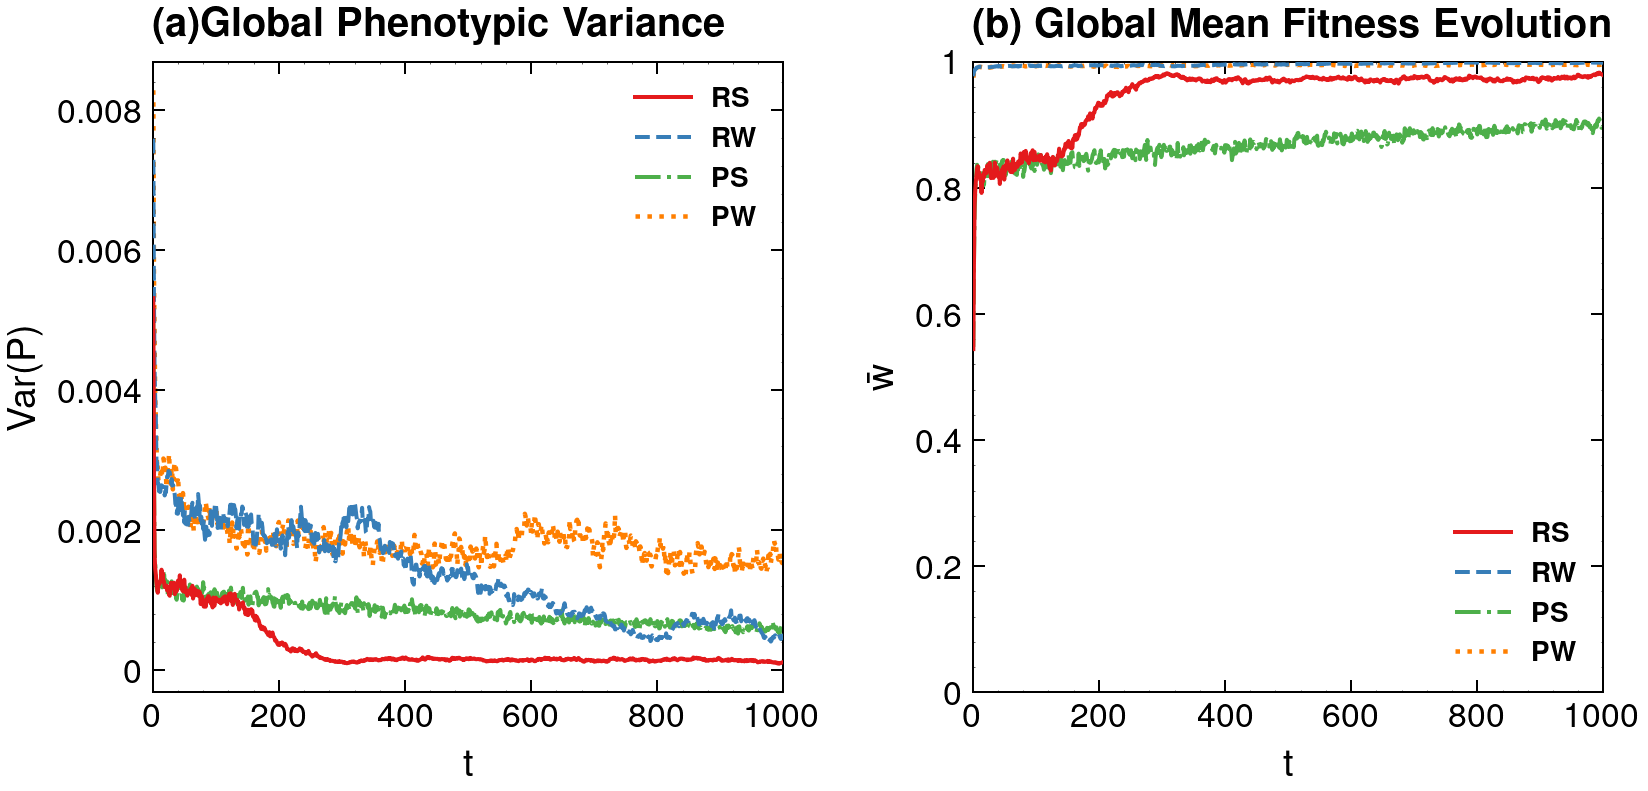

In [19]:
dados_extraidos = {}

for label, pasta in dirs.items():
    t_arr, var_arr, fit_arr = extrair_dinamica_global(pasta, t_max=1000)
    dados_extraidos[label] = {'t': t_arr, 'var': var_arr, 'fit': fit_arr}


fig = plt.figure(figsize=(26, 12))
gs = gridspec.GridSpec(1, 2, wspace=0.30)

ax1 = fig.add_subplot(gs[0, 0])
ax1.set_box_aspect(1) 

for label, data in dados_extraidos.items():
    if len(data['t']) > 0: 
        cfg = styles[label]
        ax1.plot(data['t'], data['var'], color=cfg['c'], linestyle=cfg['ls'], 
                 linewidth=cfg['lw'], label=r'\textbf{\textsf{' + label + '}}', zorder=cfg['z'])

format_ax(ax1, major_size=SIZE_TICK, is_int=False)

ax1.set_xlabel(r'$\mathsf{t}$', fontsize=SIZE_LABEL, labelpad=15)
ax1.set_ylabel(r'$\mathsf{Var(P)}$', fontsize=SIZE_LABEL, labelpad=15)
ax1.set_title(r'\textbf{\textsf{(a)Global Phenotypic Variance}}', loc='left', fontsize=SIZE_TITLE, pad=25)
ax1.set_xlim(0, 1000)

ax1.legend(loc='best', frameon=False, fontsize=SIZE_LEGEND)

ax2 = fig.add_subplot(gs[0, 1])
ax2.set_box_aspect(1) 

for label, data in dados_extraidos.items():
    if len(data['t']) > 0:
        cfg = styles[label]
        ax2.plot(data['t'], data['fit'], color=cfg['c'], linestyle=cfg['ls'], 
                 linewidth=cfg['lw'], label=r'\textbf{\textsf{' + label + '}}', zorder=cfg['z'])

format_ax(ax2, major_size=SIZE_TICK, is_int=False)

ax2.set_xlabel(r'$\mathsf{t}$', fontsize=SIZE_LABEL, labelpad=15)
ax2.set_ylabel(r'$\mathsf{\bar{w}}$', fontsize=SIZE_LABEL, labelpad=15)
ax2.set_title(r'\textbf{\textsf{(b) Global Mean Fitness Evolution}}', loc='left', fontsize=SIZE_TITLE, pad=25)
ax2.set_ylim(0, 1)
ax2.set_xlim(0, 1000)

ax2.legend(loc='lower right', frameon=False, fontsize=SIZE_LEGEND)

plt.savefig('SM_demographic_homo.pdf', bbox_inches='tight', dpi=300)
plt.show()

# Phenotype distance and signature


In [20]:
plt.rcParams['text.usetex'] = True
plt.rcParams.update({
    'font.family': 'sans-serif',
    'text.latex.preamble': r'\usepackage{sfmath} \renewcommand{\familydefault}{\sfdefault} \normalfont',
})

def get_ordered_distance_matrix(base_path, scenario_path):
    spatial_file = os.path.join(base_path, scenario_path, 'All/data5000.dat')
    genome_file = os.path.join(base_path, scenario_path, 'phenotype/phegenome.dat')
    
    if not os.path.exists(spatial_file) or not os.path.exists(genome_file):
        return None

    df = pd.read_csv(spatial_file, sep=r'\s+', header=None,
                     names=['id', 'x', 'y', 'species', 'degree', 'phenotype', 'fitness'])
    
    with open(genome_file, 'r') as f:
        genomes = np.array([list(line.strip()) for line in f.readlines()], dtype=int)
    
    species_dist = df.groupby('species').apply(lambda g: pd.Series({
        'left': (g['x'] < 50).sum(), 'right': (g['x'] >= 50).sum()
    }), include_groups=False)
    
    spp_e1 = species_dist[species_dist['left'] >= species_dist['right']].index.tolist()
    spp_e2 = species_dist[species_dist['right'] > species_dist['left']].index.tolist()
    ordered_species = spp_e1 + spp_e2
    
    n_spp = len(ordered_species)
    n_loci = genomes.shape[1]
    
    if n_spp == 0: return None
    
    dist_matrix = np.zeros((n_spp, n_spp))
    for i, spp_a in enumerate(ordered_species):
        for j, spp_b in enumerate(ordered_species):
            if i <= j:
                gen_a = genomes[df['species'] == spp_a]
                gen_b = genomes[df['species'] == spp_b]
                dists = cdist(gen_a, gen_b, metric='cityblock') / n_loci
                avg_dist = np.mean(dists)
                dist_matrix[i, j] = dist_matrix[j, i] = avg_dist
    
    sequential_labels = [str(i+1) for i in range(n_spp)]
    return pd.DataFrame(dist_matrix, index=sequential_labels, columns=sequential_labels)



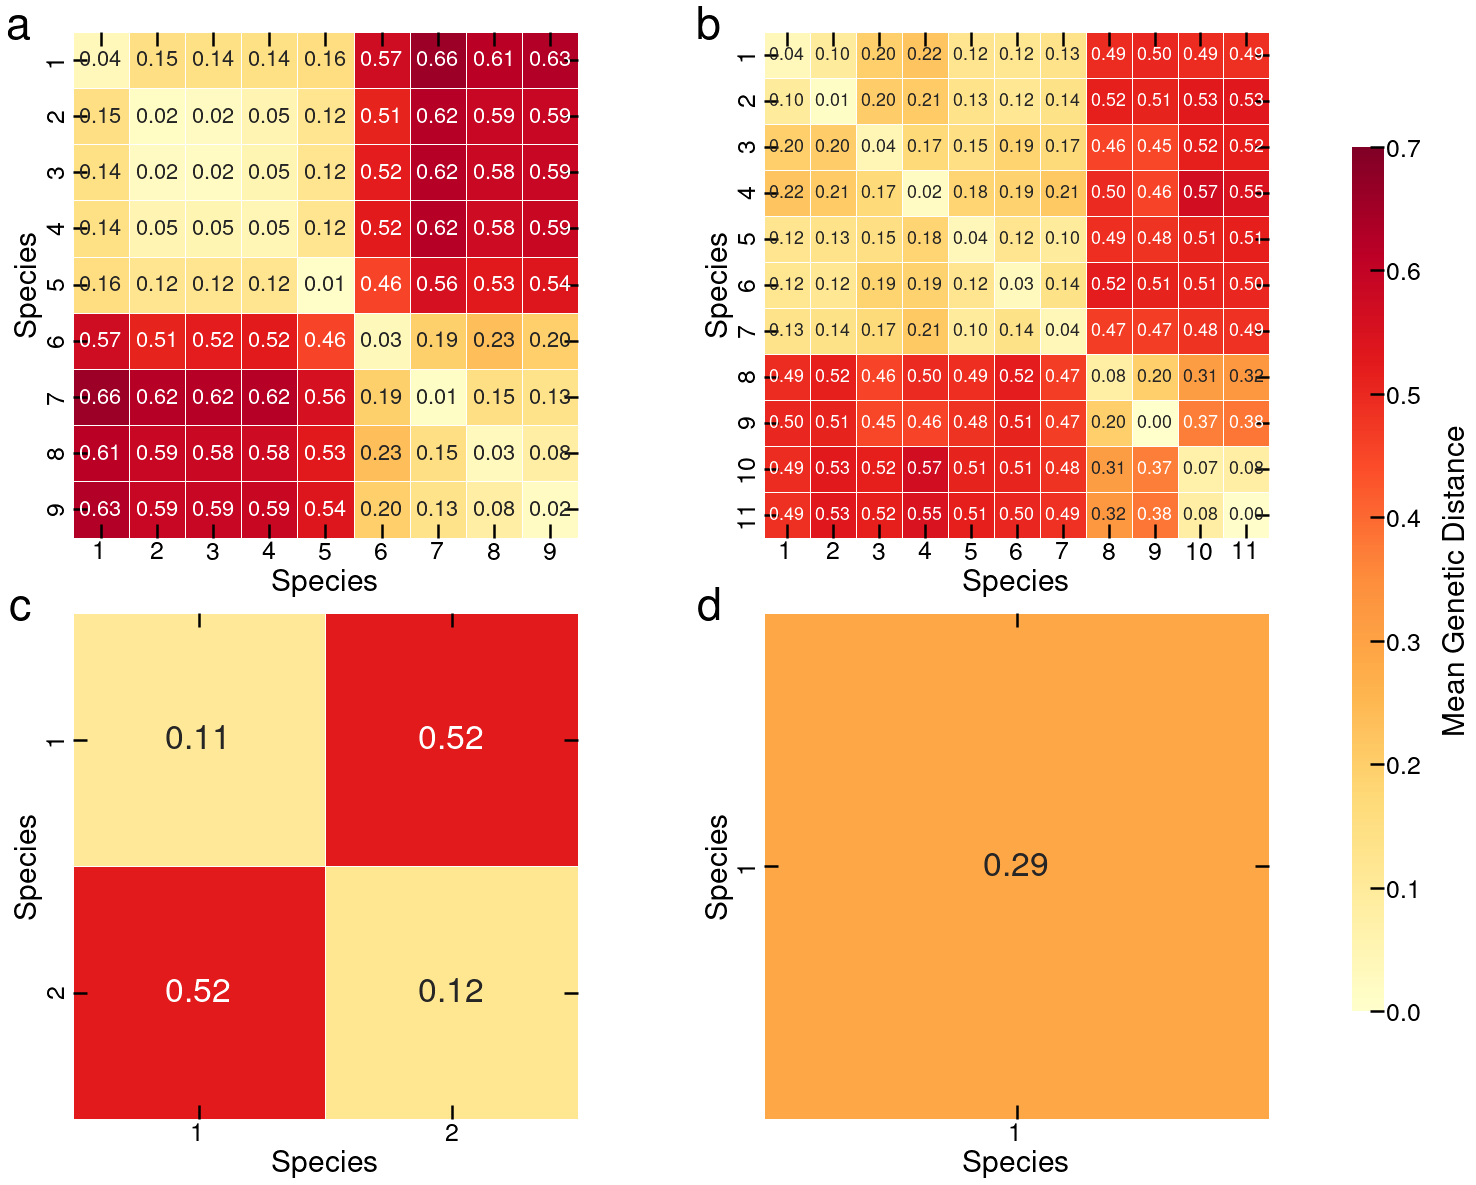

In [21]:
BASE = "code/DATA/heterogeneous/diffphen"
scenarios = [
    ("G5sigma5", "G5, $\sigma=5$"),
    ("G5sigma40", "G5, $\sigma=40$"),
    ("G30sigma5", "G30, $\sigma=5$"),
    ("G30sigma40", "G30, $\sigma=40$")
]

VMIN, VMAX = 0.0, 0.7
TAM_TITULO = 35
TAM_LABEL = 30
TAM_TICKS = 25
TAM_ANNOT_BASE = 22 
LETRAS = ['a', 'b', 'c', 'd']

fig, axes = plt.subplots(2, 2, figsize=(22, 20))
axes = axes.flatten()

cbar_ax = fig.add_axes([0.93, 0.2, 0.02, 0.6]) 

for i, (path, label) in enumerate(scenarios):
    ax = axes[i]
    df_dist = get_ordered_distance_matrix(BASE, path)
    
    ax.text(-0.08, 1.05, LETRAS[i], transform=ax.transAxes, 
            fontsize=TAM_TITULO + 10, fontweight='bold', va='top', ha='right')

    if df_dist is not None:
        n_spp = len(df_dist)
        
        if n_spp > 10:
            current_annot_size = TAM_ANNOT_BASE - 4 
        elif n_spp <= 3:
            current_annot_size = TAM_ANNOT_BASE + 12
        else:
            current_annot_size = TAM_ANNOT_BASE

        sns.heatmap(df_dist, 
                    ax=ax, 
                    annot=True, 
                    fmt=".2f", 
                    cmap="YlOrRd", 
                    vmin=VMIN, vmax=VMAX,
                    cbar=(i == 0), 
                    cbar_ax=cbar_ax, 
                    square=True, 
                    annot_kws={'size': current_annot_size, 'weight': 'bold'},
                    linewidths=0.5 if n_spp < 15 else 0.1)

        ax.set_xlabel(r'$\mathsf{Species}$', fontsize=TAM_LABEL)
        ax.set_ylabel(r'$\mathsf{Species}$', fontsize=TAM_LABEL)
        ax.tick_params(labelsize=TAM_TICKS)
    else:
        ax.text(0.5, 0.5, "No Data", ha='center', va='center', fontsize=TAM_TICKS)
        ax.set_axis_off()

cbar_ax.tick_params(labelsize=TAM_TICKS)
cbar_ax.set_ylabel(r'$\mathsf{Mean\ Genetic\ Distance}$', fontsize=TAM_LABEL, labelpad=20)

plt.subplots_adjust(right=0.9, left=0.1, hspace=0.15, wspace=0.2)

plt.savefig('matrix.pdf', dpi=300, bbox_inches='tight')
plt.show()


In [22]:
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'axes.labelweight': 'bold',
    'axes.titleweight': 'bold',
})

def get_signatures(base_path, scenario_path):
    spatial_file = os.path.join(base_path, scenario_path, 'All/data5000.dat')
    genome_file = os.path.join(base_path, scenario_path, 'phenotype/phegenome.dat')
    
    if not os.path.exists(spatial_file) or not os.path.exists(genome_file):
        return None, None

    df = pd.read_csv(spatial_file, sep=r'\s+', header=None,
                     names=['id', 'x', 'y', 'species', 'degree', 'phenotype', 'fitness'])
    
    with open(genome_file, 'r') as f:
        genomes = np.array([list(line.strip()) for line in f.readlines()], dtype=int)
    
    df_gen = pd.DataFrame(genomes)
    df_gen['species'] = df['species'].values
    df_gen['x'] = df['x'].values
    
    if df['species'].nunique() > 1:
        signatures = df_gen.drop(columns='x').groupby('species').mean()
        species_dist = df.groupby('species').apply(lambda g: pd.Series({
            'left': (g['x'] < 50).sum(), 'right': (g['x'] >= 50).sum()
        }), include_groups=False)
        
        sig_e1 = signatures.loc[species_dist[species_dist['left'] >= species_dist['right']].index]
        idx_e2 = species_dist[species_dist['right'] > species_dist['left']].index
        sig_e2 = signatures.loc[idx_e2]
        is_single_species = False
    else:
        sig_e1 = df_gen[df_gen['x'] < 50].drop(columns=['species', 'x']).mean().to_frame().T
        sig_e2 = df_gen[df_gen['x'] >= 50].drop(columns=['species', 'x']).mean().to_frame().T
        sig_e1.index, sig_e2.index = ['Pop. E1'], ['Pop. E2']
        is_single_species = True

    return sig_e1, sig_e2, is_single_species


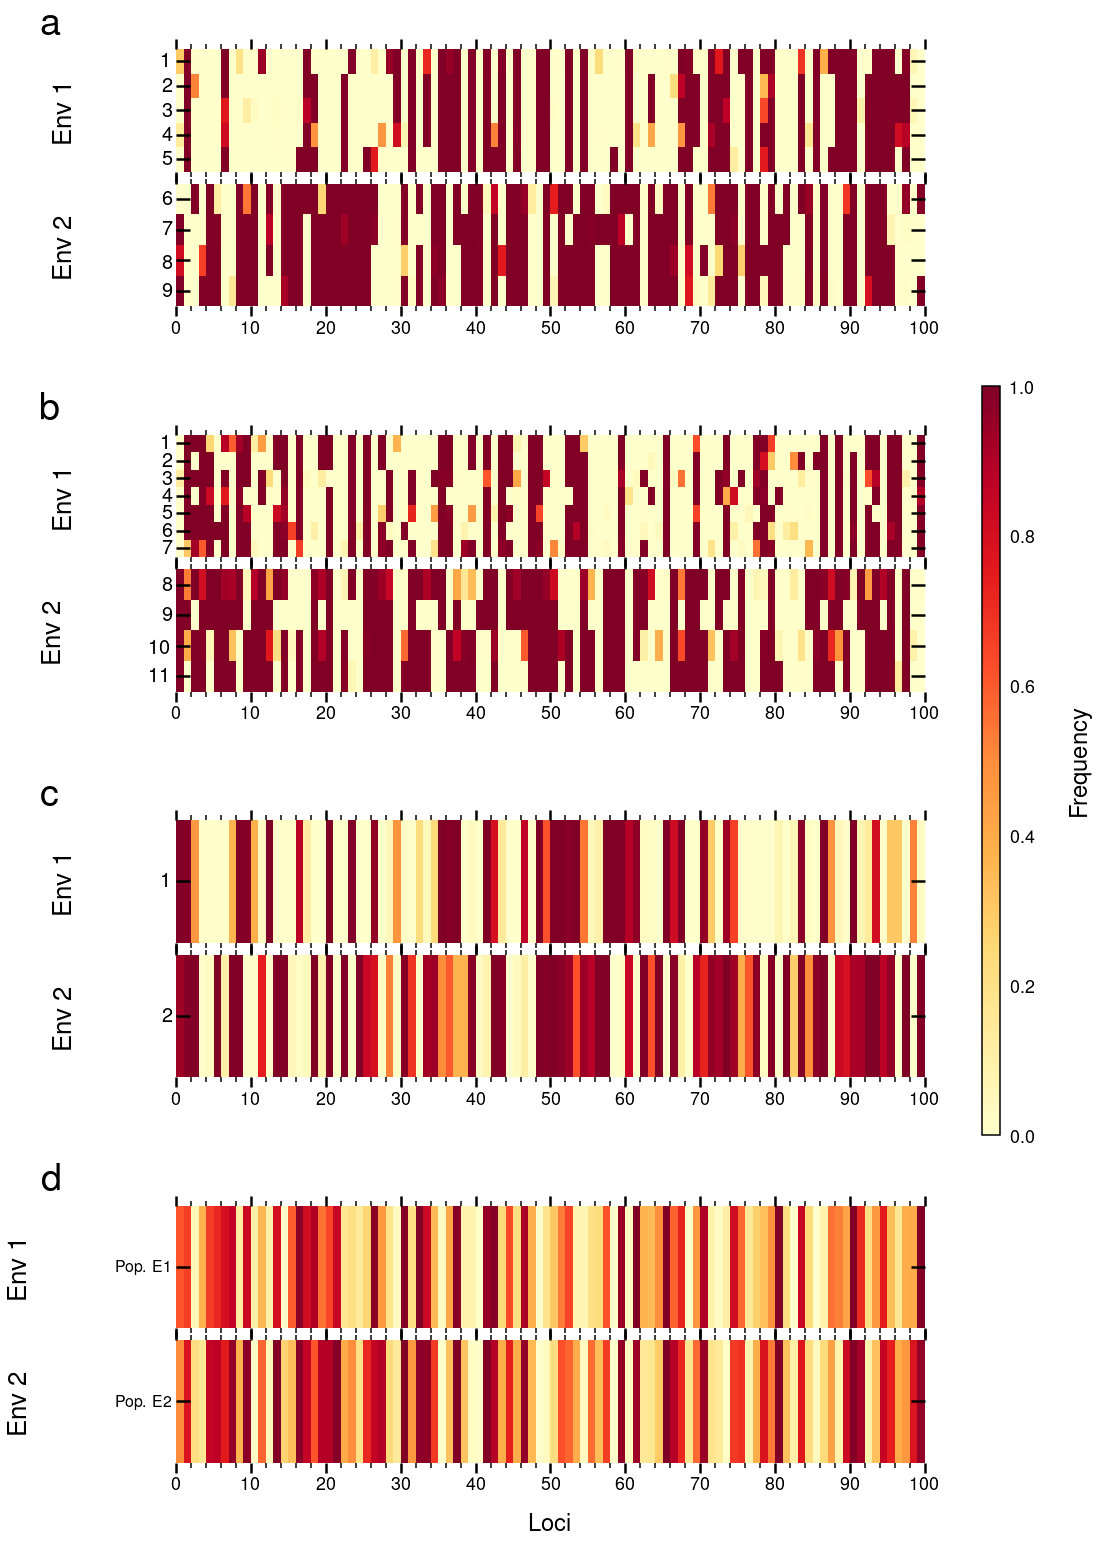

In [23]:
BASE = "code/DATA/heterogeneous/diffphen" 
CENARIOS = [
    ("G5sigma5", "G5, sigma=5"), 
    ("G5sigma40", "G5, sigma=40"), 
    ("G30sigma5", "G30, sigma=5"), 
    ("G30sigma40", "G30, sigma=40")
]
LETRAS = ['a', 'b', 'c', 'd']

TAM_LETRA_PAINEL = 38  
TAM_LABEL_AMBIENTE = 26 
TAM_LABEL_ESPECIES = 20 
TAM_TICKS = 18         
TAM_LABEL_LOCI = 24

fig = plt.figure(figsize=(16, 26))
outer_grid = gridspec.GridSpec(4, 1, hspace=0.5, left=0.2, right=0.85)

for i, (folder, title_label) in enumerate(CENARIOS):
    sig_e1, sig_e2, is_single = get_signatures(BASE, folder)
    if sig_e1 is None: continue
    
    if is_single:
        labels_e1 = ["Pop. E1"]
        labels_e2 = ["Pop. E2"]
    else:
        n_e1 = len(sig_e1)
        n_e2 = len(sig_e2)
        labels_e1 = [str(j + 1) for j in range(n_e1)]
        labels_e2 = [str(j + 1 + n_e1) for j in range(n_e2)]
    
    inner_grid = gridspec.GridSpecFromSubplotSpec(2, 1, subplot_spec=outer_grid[i], hspace=0.1)
    
    ax1 = fig.add_subplot(inner_grid[0, 0])
    ax2 = fig.add_subplot(inner_grid[1, 0])

    heatmap_kws = {'cmap': "YlOrRd", 'cbar': False, 'vmin': 0, 'vmax': 1, 'linewidths': 0}
    sns.heatmap(sig_e1, ax=ax1, **heatmap_kws)
    sns.heatmap(sig_e2, ax=ax2, **heatmap_kws)

    ax1.text(-0.18, 1.35, LETRAS[i], transform=ax1.transAxes, 
             fontsize=TAM_LETRA_PAINEL, fontweight='bold', va='top')

    for ax, sig_data, env_name, y_labels in zip([ax1, ax2], [sig_e1, sig_e2], ['Env 1', 'Env 2'], [labels_e1, labels_e2]):
        ax.set_ylabel(env_name, fontsize=TAM_LABEL_AMBIENTE, fontweight='bold', labelpad=85)
        ax.set_yticks(np.arange(len(sig_data)) + 0.5)
        
        f_size = TAM_LABEL_ESPECIES - 4 if is_single else TAM_LABEL_ESPECIES
        ax.set_yticklabels(y_labels, rotation=0, fontsize=f_size)
        
        n_loci = sig_data.shape[1]
        tick_pos = np.arange(0, n_loci + 1, 10)
        ax.set_xticks(tick_pos)
        ax.xaxis.set_minor_locator(MultipleLocator(2))
        ax.tick_params(axis='x', which='major', labelsize=TAM_TICKS, length=10, width=2.5, direction='out', bottom=True)
        ax.tick_params(axis='x', which='minor', length=5, width=1.5, direction='out', bottom=True)
        
        if ax == ax1:
            ax.set_xticklabels([])
        else:
            ax.set_xticklabels([str(int(x)) for x in tick_pos])
            if i == 3: 
                ax.set_xlabel('Loci', fontsize=TAM_LABEL_LOCI, labelpad=20)

cbar_ax = fig.add_axes([0.90, 0.30, 0.015, 0.4]) 
sm = plt.cm.ScalarMappable(cmap="YlOrRd", norm=plt.Normalize(vmin=0, vmax=1))
cbar = fig.colorbar(sm, cax=cbar_ax)
cbar.ax.tick_params(labelsize=TAM_TICKS, direction='in', length=0, pad=10)
cbar.set_label('Frequency', size=TAM_LABEL_LOCI, labelpad=35, fontweight='bold')
cbar.outline.set_linewidth(1.5)

plt.savefig('Signatures.pdf', dpi=300, bbox_inches='tight')
plt.show()



# Boundary

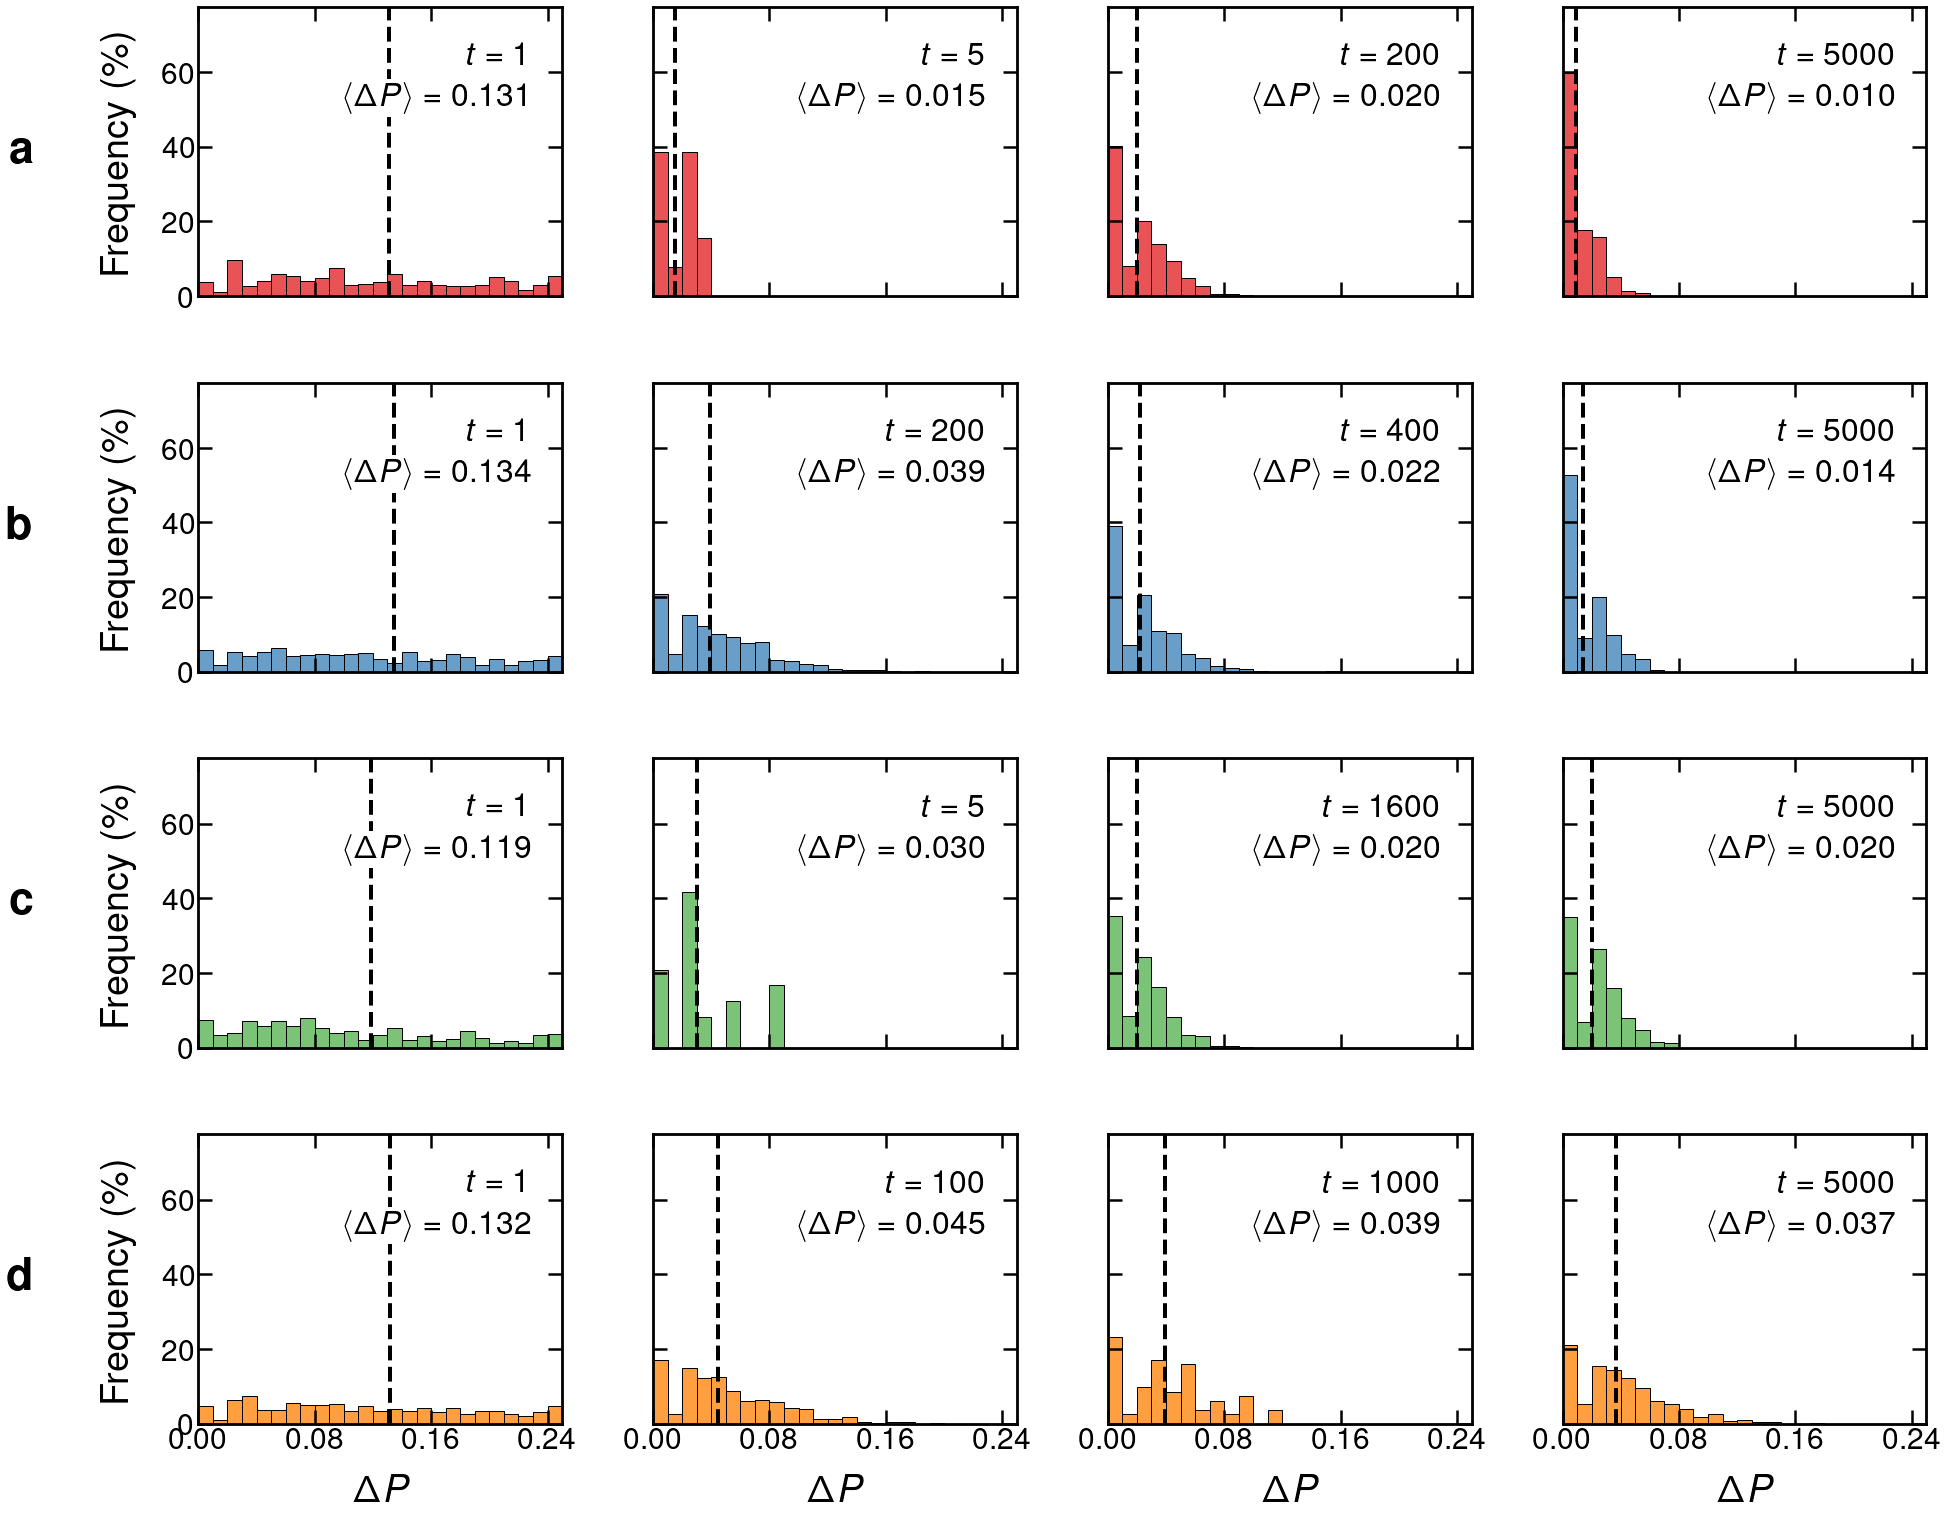

In [24]:
plt.rcParams.update({
    'text.usetex': True,
    'font.family': 'sans-serif',
    'pdf.fonttype': 42,
    'axes.labelsize': 38,      
    'xtick.labelsize': 30,     
    'ytick.labelsize': 30,     
    'axes.linewidth': 2.8,     
    'xtick.major.size': 14,    
    'xtick.major.width': 2.5,  
    'ytick.major.size': 14,    
    'ytick.major.width': 2.5,  
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True
})


Htimes = {
    r'$G = 0.05, \sigma_e = 0.05$': [1, 5, 200, 5000],
    r'$G = 0.05, \sigma_e = 0.40$': [1, 200, 400, 5000],
    r'$G = 0.30, \sigma_e = 0.05$': [1, 5, 1600, 5000],
    r'$G = 0.30, \sigma_e = 0.40$': [1, 100, 1000, 5000],
}

directories = {
    r'$G = 0.05, \sigma_e = 0.05$': 'DATA/phenotype/G5sigma5/diff/',
    r'$G = 0.05, \sigma_e = 0.40$': 'DATA/phenotype/G5sigma40/diff/',
    r'$G = 0.30, \sigma_e = 0.05$': 'DATA/phenotype/G30sigma5/diff/',
    r'$G = 0.30, \sigma_e = 0.40$': 'DATA/phenotype/G30sigma40/diff/',
}

colors = {
    r'$G = 0.05, \sigma_e = 0.05$': '#e41a1c', 
    r'$G = 0.05, \sigma_e = 0.40$': '#377eb8', 
    r'$G = 0.30, \sigma_e = 0.05$': '#4daf4a', 
    r'$G = 0.30, \sigma_e = 0.40$': '#ff7f00', 
}


plot_data = {}
max_percent = 0

for label, folder in directories.items():
    if not os.path.exists(folder): continue
    files = sorted(glob.glob(os.path.join(folder, "diff_*.txt")), 
                   key=lambda x: int(x.split('_')[-1].split('.')[0]))
    scenario_raw = {}
    for f in files:
        it = int(f.split('_')[-1].split('.')[0])
        try:
            data = np.abs(np.loadtxt(f))
            if data.size < 2: continue
            scenario_raw[it] = data
        except: continue
    
    plot_data[label] = {}
    for target_t in Htimes[label]:
        if not scenario_raw: continue
        actual_t = min(scenario_raw.keys(), key=lambda x: abs(x - target_t))
        val_data = scenario_raw[actual_t]
        plot_data[label][actual_t] = val_data
        
        counts, _ = np.histogram(val_data, bins=25, range=(0, 0.25))
        current_max = (counts.max() / counts.sum()) * 100
        if current_max > max_percent: max_percent = current_max

fixed_ylim = max_percent * 1.3 


fig, axes = plt.subplots(4, 4, figsize=(30, 24), sharex=True, sharey=True)
plt.subplots_adjust(left=0.15, top=0.92, bottom=0.1, right=0.95, wspace=0.25, hspace=0.3)

row_letters = ['a', 'b', 'c', 'd']
scenario_list = list(Htimes.keys())

for i, label in enumerate(scenario_list):
    if label not in plot_data: continue
    times_sorted = sorted(plot_data[label].keys())
    
    for j, actual_t in enumerate(times_sorted):
        ax = axes[i, j]
        val_data = plot_data[label][actual_t]
        

        sns.histplot(val_data, bins=25, binrange=(0, 0.25), kde=False, ax=ax, 
                     color=colors[label], stat='percent', alpha=0.75, edgecolor='black')
        

        mu = np.mean(val_data)
        ax.axvline(mu, color='black', linestyle='--', lw=4, zorder=5)
        
        ax.xaxis.set_major_locator(MaxNLocator(nbins=4))
        
        common_bbox = dict(facecolor='white', alpha=1.0, edgecolor='none', pad=3)
        

        ax.text(0.92, 0.88, f'$t = {actual_t}$', transform=ax.transAxes, 
                fontsize=32, fontweight='bold', va='top', ha='right',
                bbox=common_bbox, zorder=10)
        

        ax.text(0.92, 0.74, f'$\\langle \\Delta P \\rangle = {mu:.3f}$', 
                transform=ax.transAxes, fontsize=32, va='top', ha='right',
                bbox=common_bbox, zorder=10)


        if j == 0:
            ax.text(-0.45, 0.5, f'\\textbf{{{row_letters[i]}}}', transform=ax.transAxes, 
                    fontsize=45, fontweight='bold', va='center', ha='right')
            ax.set_ylabel('Frequency (\%)', labelpad=25)
        
        ax.set_ylim(0, fixed_ylim)
        ax.set_xlim(0, 0.25)
        if i == 3: ax.set_xlabel(r'$\Delta P$', labelpad=20)

plt.savefig('dist.pdf', dpi=300, bbox_inches='tight')
plt.show()



# Analyses parameters

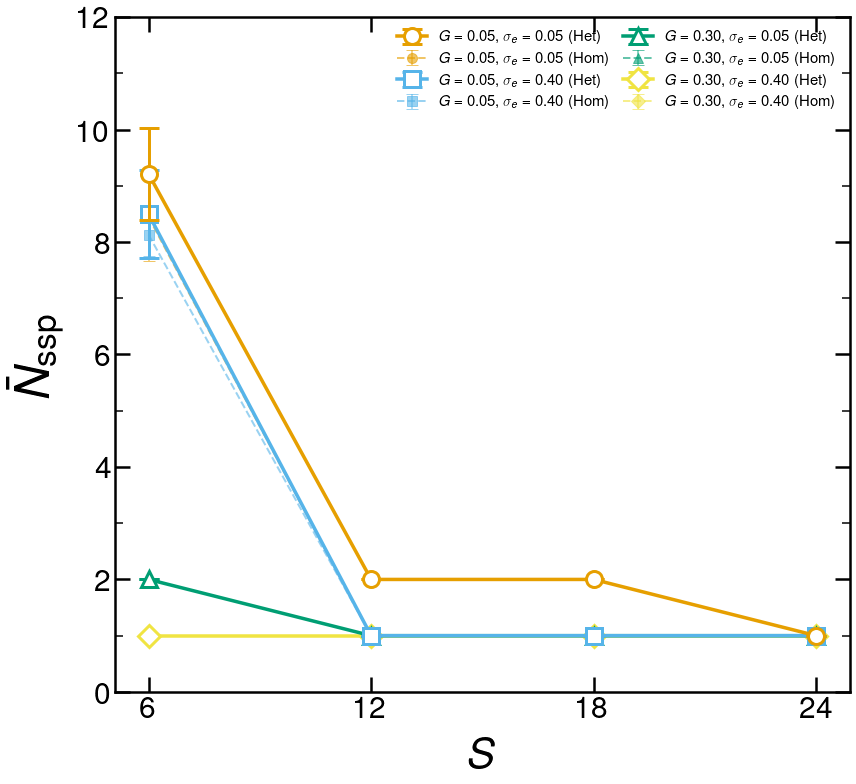

In [26]:
import re
warnings.simplefilter(action='ignore', category=FutureWarning)

plt.rcParams['text.usetex'] = True
plt.rcParams.update({
    'font.family': 'sans-serif',
    'text.latex.preamble': r'\usepackage{sfmath} \renewcommand{\familydefault}{\sfdefault} \normalfont',
})

base_path = "code/DATA/radiusS/"
modes = ["heterogeneous", "homogeneous"]
file_prefix = "evolution_global"
coluna_analise = 1  
fracao_janela_temporal = 0.05 

results = []

for mode in modes:
    folder_path = os.path.join(base_path, mode)
    if not os.path.exists(folder_path): continue
    
    for root, dirs, files in os.walk(folder_path):
        replica_files = [f for f in files if f.startswith(file_prefix) and f.endswith(".dat")]
        
        if replica_files:
            folder_params = os.path.basename(root)
            parent_folder = os.path.basename(os.path.dirname(root))
            
            s_radius_match = re.search(r'S(\d+)', parent_folder)
            param_match = re.search(r'G(\d+)sigma(\d+)', folder_params)
            
            if s_radius_match and param_match:
                s_radius = int(s_radius_match.group(1))
                g_val = int(param_match.group(1))
                sigma_val = int(param_match.group(2))
                
                medias_das_replicas = []
                for f in replica_files:
                    try:
                        data = np.loadtxt(os.path.join(root, f), skiprows=1)
                        if data.ndim == 1: data = data.reshape(1, -1)
                        S_t = data[:, coluna_analise]
                        idx_inicio = int(len(S_t) * (1 - fracao_janela_temporal))
                        medias_das_replicas.append(np.mean(S_t[idx_inicio:]))
                    except: continue
                
                if medias_das_replicas:
                    results.append({
                        'S_radius': s_radius,
                        'Mean_Value': np.mean(medias_das_replicas),
                        'Std_Dev': np.std(medias_das_replicas),
                        'Mode': mode,
                        'Label_Base': rf'$G={g_val*0.01:.2f}, \sigma_e={sigma_val/100:.2f}$'
                    })

df = pd.DataFrame(results)

if not df.empty:
    fig, ax = plt.subplots(figsize=(12, 11))
    
    params_unicos = sorted(df['Label_Base'].unique())
    colors = ['#E69F00', '#56B4E9', '#009E73', '#F0E442', '#0072B2', '#D55E00', '#CC79A7']
    markers = ['o', 's', '^', 'D', 'v', 'p', 'h']

    for i, p_base in enumerate(params_unicos):
        color = colors[i % len(colors)]
        marker = markers[i % len(markers)]
        
        subset_het = df[(df['Label_Base'] == p_base) & (df['Mode'] == 'heterogeneous')].sort_values('S_radius')
        if not subset_het.empty:
            ax.errorbar(subset_het['S_radius'], subset_het['Mean_Value'], 
                        yerr=subset_het['Std_Dev'],
                        label=f'{p_base} (Het)', color=color, marker=marker, 
                        linestyle='-', linewidth=3.5, markersize=16, 
                        markerfacecolor='white', markeredgewidth=3, 
                        capsize=10,        
                        capthick=2.5,     
                        elinewidth=3,     
                        zorder=10 - i)     

        subset_hom = df[(df['Label_Base'] == p_base) & (df['Mode'] == 'homogeneous')].sort_values('S_radius')
        if not subset_hom.empty:
            ax.errorbar(subset_hom['S_radius'], subset_hom['Mean_Value'], 
                        yerr=subset_hom['Std_Dev'],
                        label=f'{p_base} (Hom)', color=color, marker=marker, 
                        linestyle='--', linewidth=2, markersize=10, 
                        markerfacecolor=color, markeredgewidth=1, 
                        capsize=6, 
                        capthick=1.5,
                        elinewidth=1.5, 
                        alpha=0.6,        
                        zorder=2)

    ax.set_xlabel(r'$S$', fontsize=42, labelpad=15)
    ax.set_ylabel(r'$\bar{N}_{\mathrm{ssp}}$', fontsize=48, labelpad=15)
    
    s_ticks = sorted(df['S_radius'].unique())
    ax.set_xticks(s_ticks)
    ax.set_xticklabels([fr'$\mathsf{{{s}}}$' for s in s_ticks])
    
    ax.set_ylim(0, 12) 
    ax.yaxis.set_major_locator(ticker.MultipleLocator(2))
    ax.yaxis.set_minor_locator(AutoMinorLocator(2))
    
    ax.tick_params(axis='both', which='major', direction='in', length=15, width=2.5, labelsize=30, top=True, right=True)
    ax.tick_params(axis='both', which='minor', direction='in', length=8, width=1.5, top=True, right=True)
    
    for spine in ax.spines.values():
        spine.set_linewidth(2.5)

    ax.legend(fontsize=15, frameon=False, loc='upper right', ncol=2, columnspacing=0.8)

    plt.tight_layout()
    plt.savefig("Svariation.pdf", dpi=600)
    plt.show()


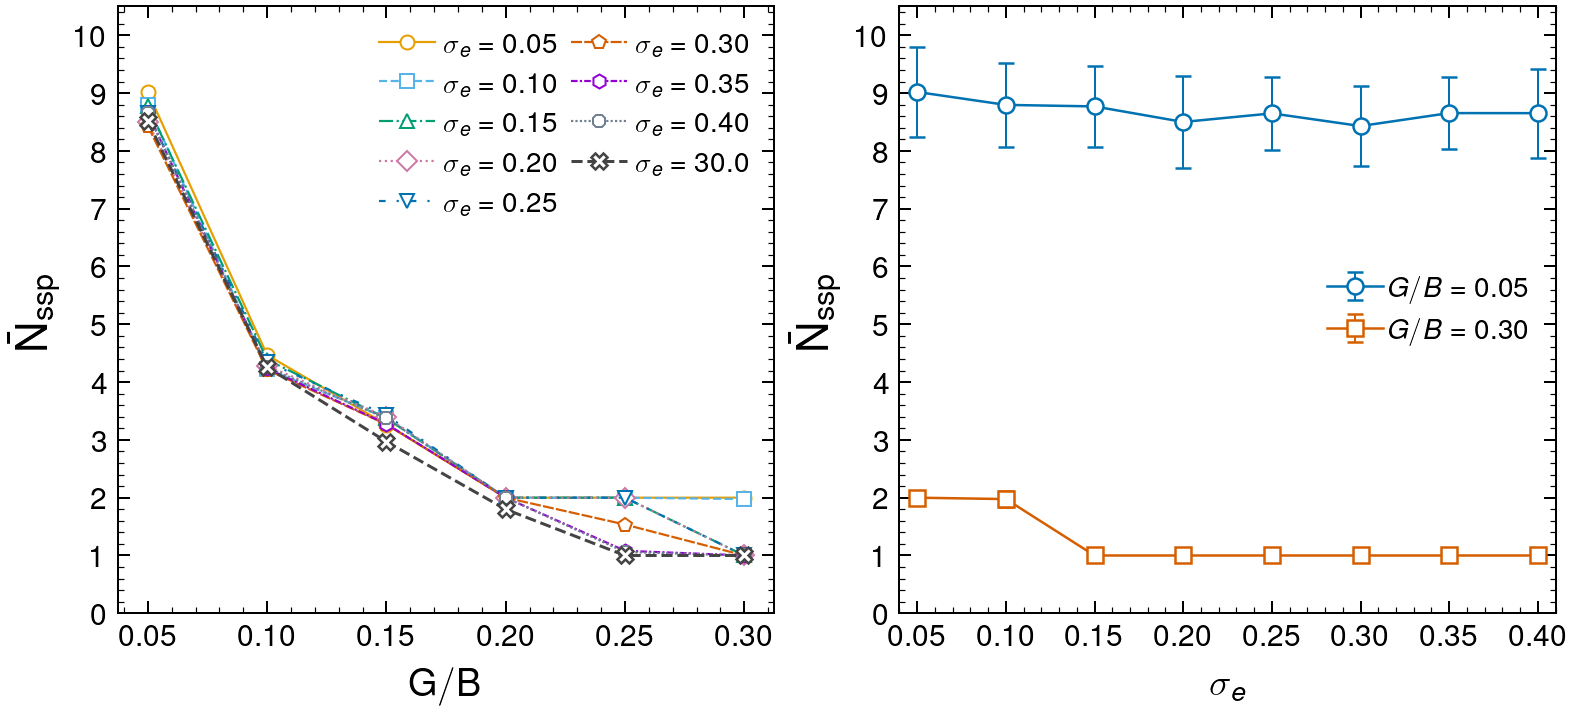

In [27]:
warnings.simplefilter(action='ignore', category=FutureWarning)

plt.rcParams['text.usetex'] = True
plt.rcParams.update({
    'font.family': 'sans-serif',
    'text.latex.preamble': r'\usepackage{sfmath} \renewcommand{\familydefault}{\sfdefault} \normalfont',
})

data_folder_local = "DATA/local/"
data_folder_het = "code/DATA/sigma30/heterogeneous/" 

g_values = [5, 10, 15, 20, 25, 30] 
sigma_values = [5, 10, 15, 20, 25, 30, 35, 40] 

n_runs = 50
col_idx = 1 
window_frac = 0.05 

all_results = []

for g in g_values:
    for s_val in sigma_values:
        run_means = []
        p1 = os.path.join(data_folder_local, f"G{g}", f"sigma{s_val}")
        p2 = os.path.join(data_folder_local, f"G{g}", f"sigma{s_val/100:.2f}")
        path = p1 if os.path.exists(p1) else p2
        
        if os.path.exists(path):
            for run in range(1, n_runs + 1):
                fpath = os.path.join(path, f"evolution_global{run}.dat")
                try:
                    data = np.loadtxt(fpath, skiprows=1)
                    if data.ndim == 1: data = data.reshape(1, -1)
                    s_t = data[:, col_idx]
                    idx = int(len(s_t) * (1 - window_frac))
                    run_means.append(np.mean(s_t[idx:]))
                except: continue
        
        if run_means:
            all_results.append({
                'G_raw': g, 'G_norm': g * 0.01, 
                'Sigma_raw': s_val, 'Sigma_norm': s_val * 0.01,
                'Mean_S': np.mean(run_means), 'Std_S': np.std(run_means)
            })

het_list = []
for g in g_values:
    run_means_het = []
    path_het = os.path.join(data_folder_het, f"G{g}")
    if os.path.exists(path_het):
        for run in range(1, n_runs + 1):
            fpath = os.path.join(path_het, f"evolution_global{run}.dat")
            try:
                data = np.loadtxt(fpath, skiprows=1)
                s_t = data[:, col_idx]
                idx = int(len(s_t) * (1 - window_frac))
                run_means_het.append(np.mean(s_t[idx:]))
            except: continue
    if run_means_het:
        het_list.append({'G_norm': g * 0.01, 'Mean_S': np.mean(run_means_het)})

df = pd.DataFrame(all_results)
df_het = pd.DataFrame(het_list)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(22, 10))

cb_colors = ['#E69F00', '#56B4E9', '#009E73', '#CC79A7', '#0072B2', '#D55E00', '#9400D3', '#708090']
markers = ['o', 's', '^', 'D', 'v', 'p', 'h', '8']
linestyles = ['-', '--', '-.', ':', (0, (3, 5, 1, 5)), (0, (5, 1)), (0, (3, 1, 1, 1)), (0, (1, 1))]

if not df.empty:
    sigma_unique = sorted(df['Sigma_raw'].unique())
    for i, s in enumerate(sigma_unique):
        subset = df[df['Sigma_raw'] == s].sort_values('G_norm')
        color = cb_colors[i % len(cb_colors)]
        ax1.plot(subset['G_norm'], subset['Mean_S'], 
                 marker=markers[i % len(markers)], markersize=14, markeredgewidth=2.0,
                 markerfacecolor='white', markeredgecolor=color,
                 color=color, linestyle=linestyles[i % len(linestyles)],
                 lw=2.2, label=rf'$\sigma_e = {s/100:.2f}$', zorder=10)

if not df_het.empty:
    dark_grey = '#444444' 
    ax1.plot(df_het['G_norm'], df_het['Mean_S'], color=dark_grey, linestyle='--', linewidth=3,
             marker='X', markersize=16, markeredgecolor=dark_grey, 
             markerfacecolor='white', markeredgewidth=2.5,
             label=r'$\sigma_e = 30.0$', zorder=15)

g_targets = [5, 30]
styles_g = {
    5:  {'label': r'$G/B = 0.05$', 'color': '#0072B2', 'marker': 'o'},
    30: {'label': r'$G/B = 0.30$', 'color': '#D55E00', 'marker': 's'}
}

for g in g_targets:
    subset = df[df['G_raw'] == g].sort_values('Sigma_norm')
    ax2.errorbar(subset['Sigma_norm'], subset['Mean_S'], yerr=subset['Std_S'],
                 label=styles_g[g]['label'], color=styles_g[g]['color'],
                 marker=styles_g[g]['marker'], markersize=16, markerfacecolor='white',
                 markeredgewidth=2.5, lw=2.5, capsize=8, capthick=2, elinewidth=2,
                 linestyle='-', zorder=10)

for i, ax in enumerate([ax1, ax2]):
    ax.set_ylim(0, 10.5)
    ax.yaxis.set_major_locator(ticker.MultipleLocator(1))
    ax.tick_params(axis='both', which='major', direction='in', length=12, width=2, labelsize=30, top=True, right=True, pad=10)
    ax.tick_params(axis='both', which='minor', direction='in', length=6, width=1.2, top=True, right=True)
    ax.xaxis.set_minor_locator(AutoMinorLocator(5))
    ax.yaxis.set_minor_locator(AutoMinorLocator(5))
    for spine in ax.spines.values(): spine.set_linewidth(2)
    
    if i == 0:
        ax.set_xlabel(r'$\mathsf{G/B}$', fontsize=38, labelpad=16)
        ax.set_ylabel(r'$\mathsf{\bar{N}_{ssp}}$', fontsize=44, labelpad=16)
        ax.xaxis.set_major_locator(ticker.MultipleLocator(0.05))
        ax.legend(fontsize=28, frameon=False, loc='upper right', ncol=2, handletextpad=0.3, columnspacing=0.5)
    else:
        ax.set_xlabel(r'$\sigma_e$', fontsize=38, labelpad=16)
        ax.set_ylabel(r'$\mathsf{\bar{N}_{ssp}}$', fontsize=44, labelpad=16)
        ax.xaxis.set_major_locator(ticker.MultipleLocator(0.05))
        ax.xaxis.set_major_formatter(ticker.FormatStrFormatter(r'$\mathsf{%.2f}$'))
        ax.set_xlim(0.04, 0.41)
        ax.legend(fontsize=28, frameon=False, loc='center right', handletextpad=0.2)

plt.tight_layout()
plt.savefig("richness.pdf", dpi=600, bbox_inches='tight')
plt.show()
